In [1]:
import pandas as pd

In [2]:
import pandas as pd

rheo_xl = pd.ExcelFile("/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/RHEO/2026-07-07/2026-07-07-RHEO-UAFW.xls")
print(rheo_xl.sheet_names)

['Details', 'Flow sweep - 1']


In [25]:
import pandas as pd
# if you want a df of the details, use:
# details_df = pd.read_excel("path_to_excel_file", sheet_name = "Details", header = 1)

def extract_data(path): 
    import pandas as pd
    # Read in original file 
    xl = pd.ExcelFile(path) 
    all_sheets = xl.sheet_names 
    print(all_sheets)
    
    data_sheets = all_sheets[1:] 
    df_list = [] 
    
    for sheet in data_sheets: 
        sheet_df = pd.read_excel(path, sheet_name=sheet, header=1) 
        
        # extract the units from the first row of data (index 0)
        units = sheet_df.iloc[0].fillna('').astype(str).tolist()
        
        # combine old column names with the units
        new_columns = []
        for col, unit in zip(sheet_df.columns, units):
            clean_col = col.split('.')[0] if '.' in col else col
            if unit:
                new_columns.append(f"{clean_col} ({unit})")
            else:
                new_columns.append(clean_col)
                
        # assign the new combined names back to the dataframe columns
        sheet_df.columns = new_columns
        
        # drop units row from the data
        sheet_df = sheet_df.drop(index=0).reset_index(drop=True)
        
        # add source sheet column
        sheet_df['Source Sheet'] = sheet 
        df_list.append(sheet_df) 
        
    # Vertically stack all the sheets together into one final df 
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # convert to float
    # errors='coerce' turns any unconvertible text or bad data into NaN safely
    for col in combined_df.columns:
        if col != 'Source Sheet':
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # make sure source sheet is last column in final df
    cols = [col for col in combined_df.columns if col != 'Source Sheet'] + ['Source Sheet']
    combined_df = combined_df[cols]
    
    return combined_df

In [4]:
rheo_df = extract_data("/Users/mauriellenoto/Desktop/seager/ionicliquids/isn/RHEO/2026-07-07/2026-07-07-RHEO-UAFW.xls")
print(rheo_df["Viscosity (Pa.s)"].max())
rheo_df.head()

['Details', 'Flow sweep - 1']
1.07673


,Stress (Pa),Shear rate (1/s),Viscosity (Pa.s),Step time (s),Temperature (°C),Normal stress (Pa),Source Sheet
0,0.020445,0.100005,0.204441,34.9900,25,-133.581,Flow sweep - 1
1,0.030948,0.125876,0.245860,70.0652,25,-132.788,Flow sweep - 1
2,0.170645,0.158485,1.076730,105.0990,25,-133.951,Flow sweep - 1
3,0.162386,0.199529,0.813847,140.1510,25,-132.693,Flow sweep - 1
4,0.171903,0.251189,0.684358,175.2300,25,-134.291,Flow sweep - 1


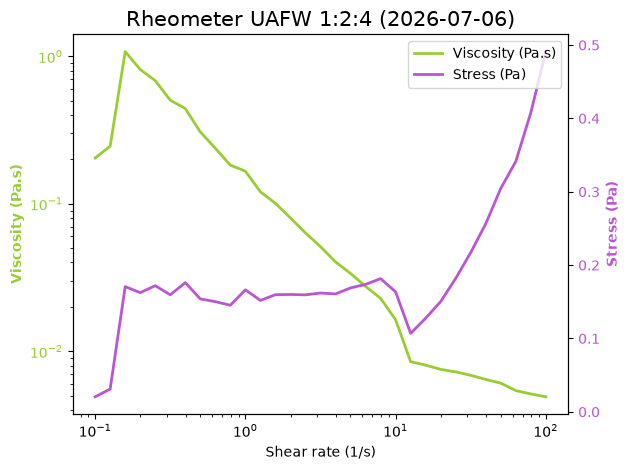

In [30]:
import matplotlib.pyplot as plt
import numpy as np

rheo_cols = list(rheo_df.columns)

y1 = "yellowgreen"
y2 = "mediumorchid"

fig, ax1 = plt.subplots()

visco = ax1.loglog(rheo_df[rheo_cols[1]], rheo_df[rheo_cols[2]], color = y1, lw = 2, label = rheo_cols[2])
ax1.set_ylabel(rheo_cols[2], color = y1, fontweight = "semibold")
ax1.set_xlabel(rheo_cols[1])
ax1.tick_params(axis = 'y', labelcolor = y1)
# min , max = 0.25,1
# ax1.set_xlim(min,max)
# ax1.set_ylim(0,0.6)

ax2 = ax1.twinx()

stress = ax2.semilogx(rheo_df[rheo_cols[1]], rheo_df[rheo_cols[0]], color = y2, lw = 2, label = rheo_cols[0])
ax2.set_ylabel(rheo_cols[0], color = y2, fontweight = "semibold")
ax2.tick_params(axis='y', labelcolor = y2)

plt.title("Rheometer UAFW 1:2:4 (2026-07-06)", fontsize = 15)
plt.legend(loc = "upper right", 
           handles = [visco[0], 
                      stress[0], 
                      ]
           )
plt.tight_layout()
plt.show()



In [27]:
rheo26_df = extract_data("/Users/mauriellenoto/Desktop/seager/ionicliquids/data/RHEO/2026-07-26/20260726-RHEO-UAFW.xls")
rheo26_df.head()

['Details', 'Flow sweep - 1']


,Stress (Pa),Shear rate (1/s),Viscosity (Pa.s),Step time (s),Temperature (°C),Normal stress (Pa),Source Sheet
0,0.000456,0.000013,34.9137,35.9025,20.7,-17.5117,Flow sweep - 1
1,0.000399,0.000010,41.2148,70.7753,20.7,-18.2885,Flow sweep - 1
2,0.000432,0.000020,21.1833,106.1140,20.7,-19.9649,Flow sweep - 1
3,0.000419,0.000020,20.4782,141.1890,20.7,-20.7981,Flow sweep - 1
4,0.000407,0.000026,15.9332,176.2770,20.7,-20.8321,Flow sweep - 1


In [ ]:
def rheo_plot(dict):
    import matplotlib.pyplot as plt
    import numpy as np


    y1 = "yellowgreen"
    y2 = "mediumorchid"

    fig, ax1 = plt.subplots()

    visco = ax1.loglog(rheo_df["Shear rate (1/s)"], rheo_df["Viscosity (Pa.s)"], 
                       color = y1, 
                       lw = 2, 
                       label = "Viscosity (Pa s)")
    
    ax1.set_ylabel("Viscosity (Pa s)", 
                   color = dict["y1_color"], 
                   fontweight = "semibold")
    
    ax1.set_xlabel("Shear rate (1/s)")

    ax1.tick_params(axis = 'y', 
                    labelcolor = dict["y1_color"])

    ax2 = ax1.twinx()

    stress = ax2.semilogx(rheo_df["Shear rate (1/s)"], rheo_df["Stress (Pa)"], 
                          color = dict["y2_color"], 
                          lw = 2, 
                          label = "Stress (Pa)")
    
    ax2.set_ylabel("Stress (Pa)", 
                   color = y2, 
                   fontweight = "semibold")
    
    ax2.tick_params(axis='y', 
                    labelcolor = dict["y2_color"])

    plt.title("Rheometer UAFW 1:2:4 (2026-07-06)", fontsize = 15)

    plt.legend(loc = "upper right", 
                handles = [
                            visco[0], 
                            stress[0], 
                            ]
                )
    
    plt.tight_layout()
    plt.show()